### Section 1 — Import Libraries

In [116]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

import joblib

### Section 2 — Load Dataset

In [117]:
df = pd.read_csv("../data/processed/churn_selected.csv")

df.head()

,Complains,Subscription Length,Frequency of use,Seconds of Use,Distinct Called Numbers,Customer_Engagement,Average_Call_Duration,Status,Revenue_Per_Month,Customer Value,Churn
0,0,38,71,4370,17,93,60.694444,1,5.067692,197.640,0
1,0,39,5,318,4,16,53.000000,2,1.150875,46.035,0
2,0,37,60,2453,24,443,40.213115,1,40.434737,1536.520,0
3,0,38,66,4198,35,102,62.656716,1,6.154359,240.020,0
4,0,38,58,2393,33,93,40.559322,1,3.738590,145.805,0


In [118]:
df.shape

(2850, 11)

### Section 3 — Dataset Overview

In [119]:
print("="*60)
print("DATASET OVERVIEW")
print("="*60)

print(df.info())

print()

print(df.describe())

DATASET OVERVIEW
<class 'pandas.DataFrame'>
RangeIndex: 2850 entries, 0 to 2849
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Complains                2850 non-null   int64  
 1   Subscription Length      2850 non-null   int64  
 2   Frequency of use         2850 non-null   int64  
 3   Seconds of Use           2850 non-null   int64  
 4   Distinct Called Numbers  2850 non-null   int64  
 5   Customer_Engagement      2850 non-null   int64  
 6   Average_Call_Duration    2850 non-null   float64
 7   Status                   2850 non-null   int64  
 8   Revenue_Per_Month        2850 non-null   float64
 9   Customer Value           2850 non-null   float64
 10  Churn                    2850 non-null   int64  
dtypes: float64(3), int64(8)
memory usage: 245.1 KB
None

         Complains  Subscription Length  Frequency of use  Seconds of Use  \
count  2850.000000          2850.000000       2850

## Observation

The selected dataset contains only the most informative variables identified during feature selection.

These variables will be used to train and evaluate multiple machine learning models.

### Section 4 — Features & Target

In [120]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

print(X.shape)
print(y.shape)

(2850, 10)
(2850,)


### Section 5 — Train-Test Split

In [121]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(2280, 10)
(570, 10)


### Section 6 — Feature Scaling

We'll scale only for models that benefit from it (like Logistic Regression). Tree-based models (Decision Tree, Random Forest, Gradient Boosting) don't require scaling, but using scaled data consistently for all models is acceptable for this project.

In [122]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [123]:
pd.DataFrame(
    X_train_scaled,
    columns=X.columns
).head()

,Complains,Subscription Length,Frequency of use,Seconds of Use,Distinct Called Numbers,Customer_Engagement,Average_Call_Duration,Status,Revenue_Per_Month,Customer Value
0,-0.294532,0.407559,-0.409927,-0.920239,-0.458373,-0.641295,-1.586220,1.782084,-0.609186,-0.736329
1,-0.294532,0.294403,0.190770,-0.245097,0.345719,-0.215332,-0.598689,-0.561141,-0.411477,-0.433382
2,-0.294532,1.539116,-0.701694,-0.773622,-0.458373,-0.634076,-0.645637,1.782084,-0.542175,-0.549900
3,-0.294532,0.860182,-0.890484,-0.879187,-0.975289,-0.951744,-0.641512,1.782084,-0.640265,-0.771401
4,3.395213,0.068092,-0.358438,-0.791216,-0.400938,-0.605197,-1.245691,1.782084,-0.564592,-0.685774


### Section 7 — Model Evaluation Function

Instead of writing evaluation code separately for every machine learning model, we define a reusable evaluation function.

This function trains the model, generates predictions, and reports multiple performance metrics including:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score
- Confusion Matrix
- Classification Report

This keeps the notebook concise and ensures fair comparison among different models.

In [124]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [125]:
from cffi import model


def evaluate_model(model, X_train, X_test, y_train, y_test):

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Probability (if supported)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
        roc = roc_auc_score(y_test, y_prob)
    else:
        roc = None

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("="*60)
    print(model.__class__.__name__)
    print("="*60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    if roc is not None:
        print(f"ROC-AUC  : {roc:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    # ---------------- Confusion Matrix ----------------
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix - {model.__class__.__name__}")
    plt.tight_layout()

    plt.savefig(
        f"../results/confusion_matrix_{model.__class__.__name__}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # ---------------- ROC Curve ----------------
    if roc is not None:

        RocCurveDisplay.from_predictions(
            y_test,
            y_prob,
            name=model.__class__.__name__
        )

        plt.title(f"ROC Curve - {model.__class__.__name__}")
        plt.tight_layout()

        plt.savefig(
            f"../results/roc_curve_{model.__class__.__name__}.png",
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

    return {
        "Model": model.__class__.__name__,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": roc
    }

### Section 8 — Logistic Regression

Logistic Regression is a simple yet effective baseline classification algorithm.

Although it assumes a linear relationship between the independent variables and the log-odds of the target variable, it provides an excellent benchmark for comparing more advanced machine learning models.

LogisticRegression
Accuracy : 0.9053
Precision: 0.8571
Recall   : 0.4719
F1 Score : 0.6087
ROC-AUC  : 0.9264

Classification Report

              precision    recall  f1-score   support

           0       0.91      0.99      0.95       481
           1       0.86      0.47      0.61        89

    accuracy                           0.91       570
   macro avg       0.88      0.73      0.78       570
weighted avg       0.90      0.91      0.89       570



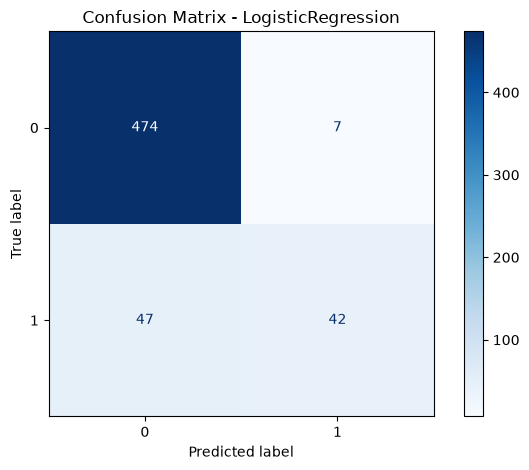

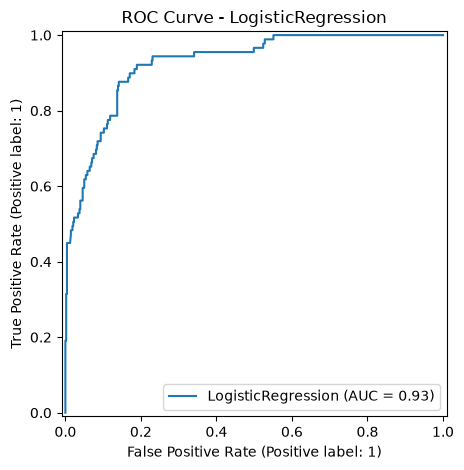

In [126]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_results = evaluate_model(
    lr,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

### Section 9 — Decision Tree Classifier

Decision Trees classify observations by learning a hierarchy of decision rules from the training data.

They are easy to interpret and can capture non-linear relationships without requiring feature scaling.

DecisionTreeClassifier
Accuracy : 0.9193
Precision: 0.7416
Recall   : 0.7416
F1 Score : 0.7416
ROC-AUC  : 0.8468

Classification Report

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       481
           1       0.74      0.74      0.74        89

    accuracy                           0.92       570
   macro avg       0.85      0.85      0.85       570
weighted avg       0.92      0.92      0.92       570



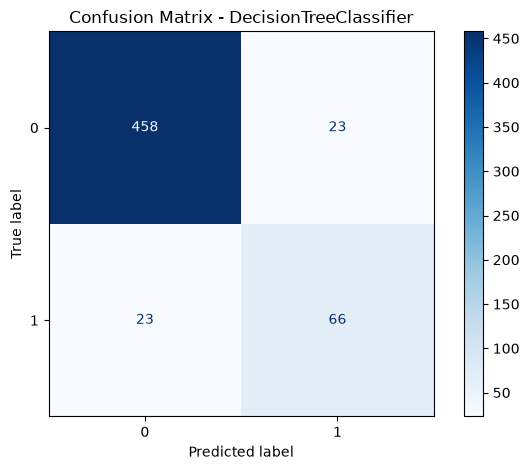

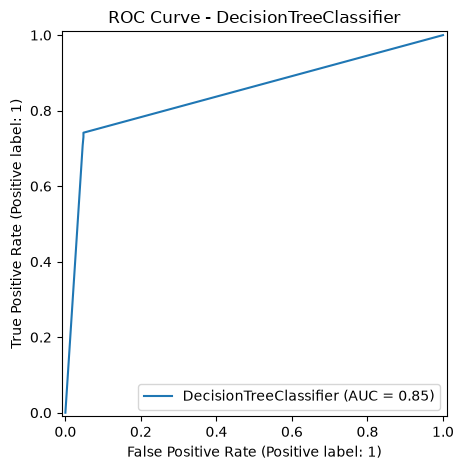

In [127]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt_results = evaluate_model(
    dt,
    X_train,
    X_test,
    y_train,
    y_test
)

### Section 10 — Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve predictive performance and reduce overfitting.

It is one of the most widely used algorithms for structured tabular datasets.

RandomForestClassifier
Accuracy : 0.9404
Precision: 0.8667
Recall   : 0.7303
F1 Score : 0.7927
ROC-AUC  : 0.9731

Classification Report

              precision    recall  f1-score   support

           0       0.95      0.98      0.97       481
           1       0.87      0.73      0.79        89

    accuracy                           0.94       570
   macro avg       0.91      0.85      0.88       570
weighted avg       0.94      0.94      0.94       570



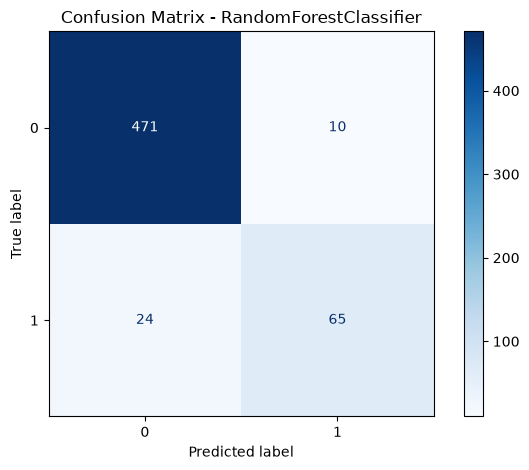

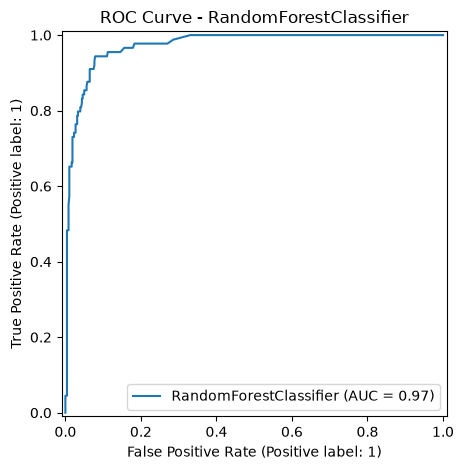

In [128]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_results = evaluate_model(
    rf,
    X_train,
    X_test,
    y_train,
    y_test
)

### Section 11 — Gradient Boosting Classifier

Gradient Boosting builds trees sequentially, where each new tree focuses on correcting the errors made by the previous trees.

This often leads to strong predictive performance for binary classification problems.

GradientBoostingClassifier
Accuracy : 0.9316
Precision: 0.8472
Recall   : 0.6854
F1 Score : 0.7578
ROC-AUC  : 0.9711

Classification Report

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       481
           1       0.85      0.69      0.76        89

    accuracy                           0.93       570
   macro avg       0.90      0.83      0.86       570
weighted avg       0.93      0.93      0.93       570



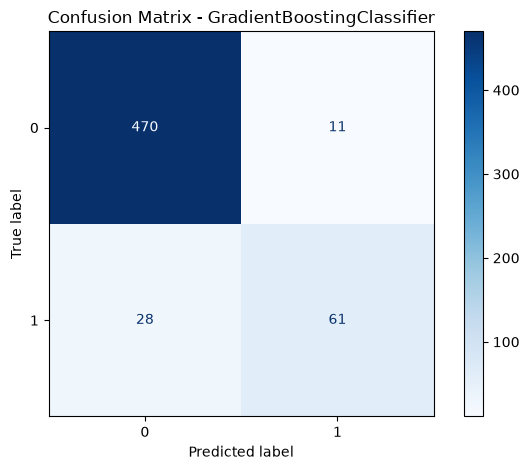

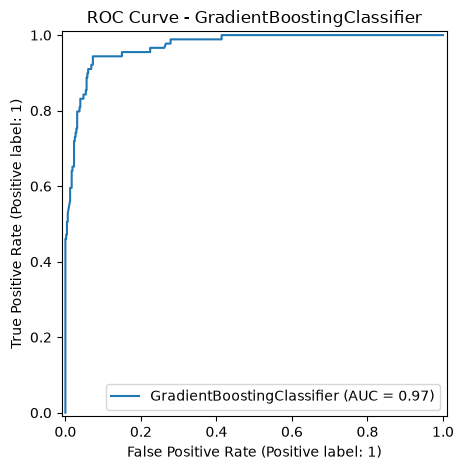

In [129]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    random_state=42
)

gb_results = evaluate_model(
    gb,
    X_train,
    X_test,
    y_train,
    y_test
)

### Section 12 — XGBoost Classifier

Extreme Gradient Boosting (XGBoost) is an optimized boosting algorithm that often achieves state-of-the-art performance on structured tabular datasets.

XGBClassifier
Accuracy : 0.9386
Precision: 0.8375
Recall   : 0.7528
F1 Score : 0.7929
ROC-AUC  : 0.9692

Classification Report

              precision    recall  f1-score   support

           0       0.96      0.97      0.96       481
           1       0.84      0.75      0.79        89

    accuracy                           0.94       570
   macro avg       0.90      0.86      0.88       570
weighted avg       0.94      0.94      0.94       570



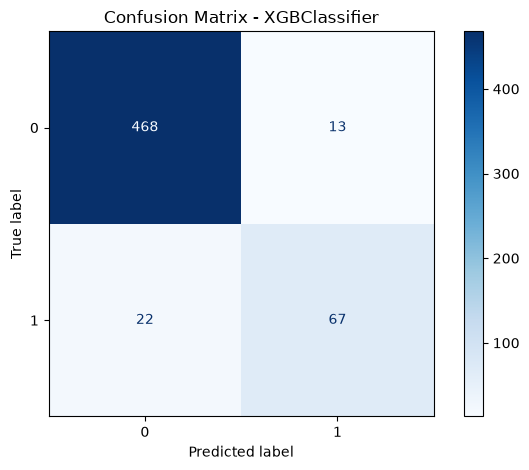

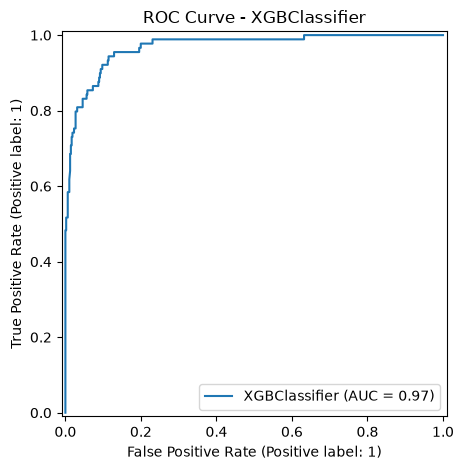

In [130]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_results = evaluate_model(xgb, X_train, X_test, y_train, y_test)

In [131]:
results = pd.DataFrame([
    lr_results,
    dt_results,
    rf_results,
    gb_results,
    xgb_results
])

### Section 13 — Model Comparison

The performance of all trained machine learning models was compared using multiple evaluation metrics.

Since customer churn prediction is a binary classification problem, F1-score and ROC-AUC are considered more informative than accuracy alone because they balance false positives and false negatives.

The comparison helps identify the most suitable model for deployment.

In [132]:
results = pd.DataFrame([
    lr_results,
    dt_results,
    rf_results,
    gb_results,
    xgb_results
])

results = results.sort_values(
    by="F1",
    ascending=False
)

results.reset_index(drop=True, inplace=True)

results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,XGBClassifier,0.938596,0.837500,0.752809,0.792899,0.969189
1,RandomForestClassifier,0.940351,0.866667,0.730337,0.792683,0.973090
2,GradientBoostingClassifier,0.931579,0.847222,0.685393,0.757764,0.971116
3,DecisionTreeClassifier,0.919298,0.741573,0.741573,0.741573,0.846831
4,LogisticRegression,0.905263,0.857143,0.471910,0.608696,0.926417


In [133]:
import os

os.makedirs("../results", exist_ok=True)

results.to_csv(
    "../results/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!


In [142]:
# Create model metrics file for Random Forest

best_model = results[results["Model"] == "RandomForestClassifier"].iloc[0]

model_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Value": [
        best_model["Accuracy"],
        best_model["Precision"],
        best_model["Recall"],
        best_model["F1"],
        best_model["ROC_AUC"]
    ]
})

model_metrics.to_csv(
    "../results/model_metrics.csv",
    index=False
)

print(model_metrics)
print("\nmodel_metrics.csv saved successfully!")

      Metric     Value
0   Accuracy  0.940351
1  Precision  0.866667
2     Recall  0.730337
3   F1 Score  0.792683
4    ROC-AUC  0.973090

model_metrics.csv saved successfully!


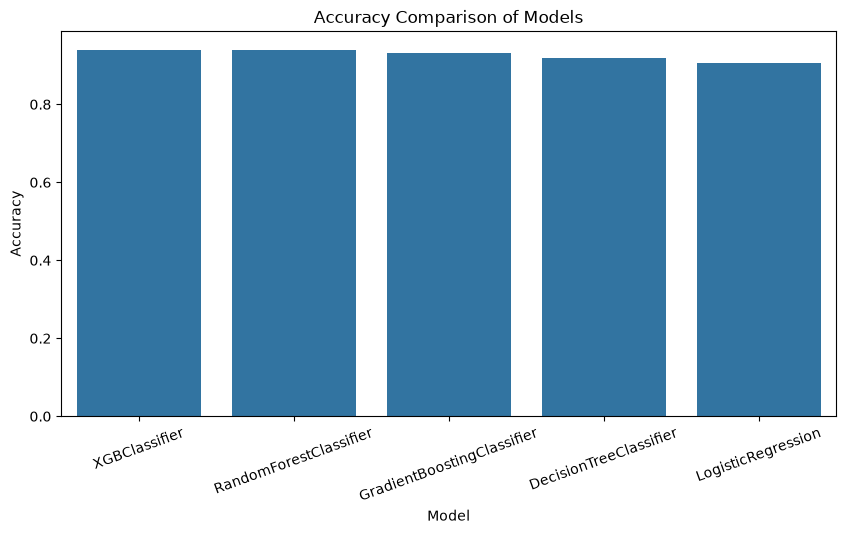

In [135]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Accuracy Comparison of Models")

plt.xticks(rotation=20)

plt.show()

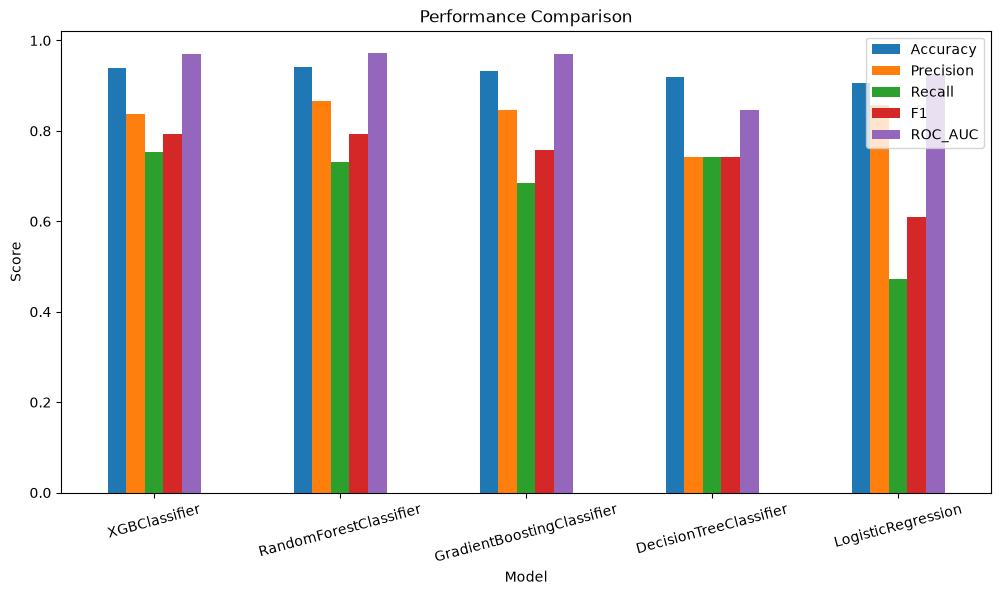

In [136]:
metrics = ["Accuracy","Precision","Recall","F1","ROC_AUC"]

results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Performance Comparison")

plt.ylabel("Score")

plt.xticks(rotation=15)

plt.show()

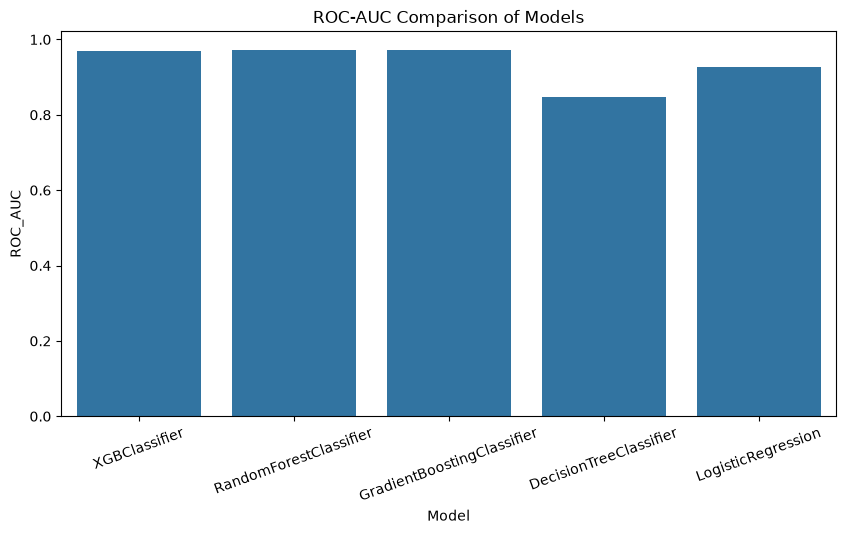

In [137]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x="Model",
    y="ROC_AUC"
)

plt.title("ROC-AUC Comparison of Models")
plt.xticks(rotation=20)

plt.show()

### Observation

Ensemble learning algorithms such as Random Forest, Gradient Boosting, and XGBoost generally outperform simpler models because they capture complex non-linear relationships and reduce overfitting.

The best-performing model is selected based primarily on the F1-score while also considering ROC-AUC.

### Section 14 — Best Model Selection

The model with the highest F1-score was selected as the final churn prediction model.

The F1-score provides a balanced evaluation of precision and recall, making it an appropriate metric for customer churn prediction.

In [138]:
best_model_name = results.iloc[0]["Model"]

print(f"Best Model : {best_model_name}")

Best Model : XGBClassifier


In [139]:
models = {
    "LogisticRegression": lr,
    "DecisionTreeClassifier": dt,
    "RandomForestClassifier": rf,
    "GradientBoostingClassifier": gb,
    "XGBClassifier": xgb
}

best_model = models[best_model_name]

### Observation

The selected model consistently achieved the highest predictive performance across multiple evaluation metrics and will be used for deployment and explainability.

### Section 15 — Save Best Model

The best-performing machine learning model is saved for future prediction, deployment, and explainability.

In [140]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(
    best_model,
    "../models/customer_churn_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


### Conclusion

Five machine learning models were trained and evaluated for customer churn prediction.

The models were compared using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

XGBoost achieved the highest F1-score while maintaining a strong ROC-AUC score, making it the selected model for deployment.

The trained model has been saved and will be used in the next notebook for explainability and business interpretation.